# B · Can we trust the risk forecast?
## Out-of-sample VaR validation

Notebook A asked **how large tomorrow's loss could be**. Notebook B asks a different question:

> **If we had issued that risk forecast repeatedly in the past, how often would realised losses have exceeded it?**

**Core learning goals**

- make one-day VaR forecasts using only information available before each outcome;
- identify and interpret VaR breaches;
- compare Historical, Rolling Normal, EWMA + Normal and GARCH + Normal VaR forecasts;
- apply Kupiec and exact-binomial coverage tests;
- test for first-order dependence in VaR breaches;
- compare VaR forecasts using a proper quantile score; and
- communicate a short evidence-based conclusion about model performance.

**Core route:** SPY investment → forecast → observe → coverage → independence → quantile score → interpret.

The **core notebook uses only the USD 1 million SPY position** so that the focus stays on forecasting and backtesting. Portfolio-style bank positions, stress testing and model-sensitivity exercises are moved to clearly labelled optional sections.

Allow about **100–120 minutes** for the core route. Optional extensions can be used for independent work or a later class.

Run in a fresh kernel from top to bottom. This notebook reads its own CSV and defines every calculation it needs. Notebook A does not need to be open.


## Open and run this notebook

Keep this notebook, `requirements.txt` and the `data` folder together. The CSV is `data/market_risk_daily.csv`. Use Python 3.12 and select your course Python environment in Jupyter.

If the required packages are not already installed, run this once in a terminal from the course folder:

```text
python -m pip install -r requirements.txt
```

To open JupyterLab from that folder:

```text
python -m jupyterlab
```

Run each cell with **Shift + Enter**. After changing settings, choose **Restart Kernel and Run All Cells**.


## Data and measurement

The supplied CSV contains daily market observations from 2015 to 2025. The ETF series were downloaded from Yahoo Finance through `yfinance` with price adjustment enabled. We calculate returns from these adjusted closing prices, which account for splits and distributions.

The FX and Treasury-yield series were downloaded alongside the ETFs. The supplied observations are aligned to SPY trading dates. Missing FX and yield levels were carried forward for at most three consecutive trading-date observations. Rows with unresolved gaps were removed during preparation.

Before calculating returns, the code checks that dates are unique and chronological, required values are present, and price/FX levels are positive.

| Column | Meaning | Calculation used here |
|---|---|---|
| SPY | Adjusted market price series | Simple percentage changes |
| QQQ, TLT | Additional adjusted market price series | Available for optional experimentation; not used in the core analysis |
| GLD | Adjusted gold ETF price series | Used in the optional bank extension |
| NZDUSD | USD per NZD | Used only in the optional bank extension |
| US10Y_YIELD_PCT | US 10-year yield in percent | Used only in the optional bank extension |

**The core analysis uses SPY.** The supplied course file also contains the variables required by the optional extensions.


In [1]:
import numpy as np  # Numerical calculations, including square roots.
import pandas as pd  # Read the CSV and organise data in tables.
import matplotlib.pyplot as plt  # Draw charts.
from matplotlib.ticker import StrMethodFormatter  # Format chart labels.
from IPython.display import display  # Show tables in the notebook.
from scipy.special import xlogy  # Evaluate x*log(y), including the limit 0*log(0)=0.
from scipy.stats import norm, chi2, binomtest  # Normal, chi-squared and binomial calculations.
from arch import arch_model  # Estimate a GARCH volatility model.

# Read the local course CSV; Date is interpreted as a date rather than text.
data = pd.read_csv("data/market_risk_daily.csv", parse_dates=["Date"])
data = data.set_index("Date")  # Identify each row by its date.
data = data.sort_index()  # Arrange observations from oldest to newest.

# Stop if dates are missing or repeated: both would affect daily returns.
assert not data.index.hasnans, "Check missing or invalid dates."
assert not data.index.has_duplicates, "Check duplicate dates."

# Identify missing columns explicitly so an error tells the student what to fix.
required = ["SPY", "QQQ", "TLT", "GLD", "NZDUSD", "US10Y_YIELD_PCT"]
missing_columns = [column for column in required if column not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Check that all required columns contain finite numeric values.
assert np.isfinite(data[required].to_numpy()).all(), "Check missing or invalid values."
assert (data[["SPY", "QQQ", "TLT", "GLD", "NZDUSD"]] > 0).all().all(), "Prices must be positive."

# Use consistent, readable chart sizes and label formats.
plt.rcParams.update({"figure.figsize": (10, 4.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2})
pd.set_option("display.max_columns", 12)

# Display the sample period and number of price observations.
print(f"Dates: {data.index.min().date()} to {data.index.max().date()}")
print(f"Price observations: {len(data):,}")
display(data.head())


Dates: 2015-01-02 to 2025-12-31
Price observations: 2,766


,SPY,QQQ,TLT,GLD,NZDUSD,US10Y_YIELD_PCT
Date,,,,,,
2015-01-02,169.687851,94.561142,92.287529,114.080002,0.779180,2.123
2015-01-05,166.623276,93.174057,93.737221,115.800003,0.766577,2.039
2015-01-06,165.053955,91.924767,95.426056,117.120003,0.770001,1.963
2015-01-07,167.110733,93.109772,95.237640,116.430000,0.774773,1.954
2015-01-08,170.076019,94.891846,93.976379,115.940002,0.777061,2.016


## Bridge from Notebook A to Notebook B

Notebook A and B use the same basic SPY setup: **USD 1 million**, **one trading day**, **99% confidence**, and **EWMA λ = 0.94**.

```text
Notebook A: estimate risk at one point in time
                ↓
Notebook B: repeat the forecast through time
                ↓
        compare forecast with outcome
                ↓
             validate
```

### Model names used in the two notebooks

- Notebook A's **Static Normal** VaR uses one mean and standard deviation estimated from the final 500 returns. Its 21- and 63-observation rolling-volatility graph is descriptive; it is not a separate VaR forecasting procedure.
- Notebook B's **Rolling Normal** VaR is the repeated-forecast version: before every test date, it re-estimates the mean and standard deviation from the preceding 500 returns.
- **EWMA + Normal** and **GARCH + Normal** make their distributional assumption explicit. EWMA and GARCH forecast conditional volatility; the standard-Normal quantile converts that volatility into 99% VaR.

There is one important implementation difference. In A, the models are compared at the end of the sample using a common recent information set. In B, we need a sequence of historical forecasts:

- Historical and Rolling Normal VaR use the preceding `WINDOW = 500` observations;
- GARCH parameters are estimated from the latest 500 returns whenever the model is refitted; and
- EWMA is recursive and therefore does not have a hard 500-observation cutoff.

These are different forecasting procedures, so the goal is not to force them to have identical memory. The essential rule is that **the outcome on date $t$ must never enter the forecast for date $t$**.

### Training and evaluation through time

Observations before `TEST_START` supply the initial estimation history, while dates from `TEST_START` onward form the evaluation period. This is a **rolling or pseudo-out-of-sample backtest**. After a test-day return has occurred, it is genuinely known and may enter the information set for later forecasts. That is not data leakage.

The backtest therefore evaluates a complete forecasting procedure, including daily updating and the pre-specified GARCH refitting schedule. A fixed-parameter holdout—estimate GARCH once before 2022, freeze $\omega$, $\alpha$ and $\beta$, but continue updating variance—is a valid alternative that asks a different question about parameter stability.

If settings such as the window, refit frequency or model specification are changed after examining the 2022–2025 results, this period has become part of model development. A completely untouched final holdout would then be needed for a final assessment.


## 1 · Continue the SPY investment

Apply historical returns to a fixed USD 1 million exposure. These are one-day fixed-exposure scenarios, not a compounded wealth series.


In [2]:
CONFIDENCE = .99  # Confidence level for one-day loss thresholds.
WINDOW = 500  # Historical observations used by rolling models.
TEST_START = "2022-01-01"  # First evaluation period; earlier data train the models.
LAMBDA = .94  # EWMA persistence.
REFIT_EVERY = 21  # Observations between GARCH parameter refits.
SPY_VALUE = 1_000_000  # Fixed USD investment exposure.
if not (SPY_VALUE > 0 and 0 < CONFIDENCE < 1 and 0 < LAMBDA < 1):
    raise ValueError("Check exposure, confidence and lambda.")
if not (isinstance(WINDOW, int) and WINDOW >= 100 and isinstance(REFIT_EVERY, int) and REFIT_EVERY >= 1):
    raise ValueError("Use a window of at least 100 and a positive integer refit interval.")
r = data.SPY.pct_change(fill_method=None).iloc[1:].rename("SPY return")  # Construct decimal returns.
scale = SPY_VALUE  # Apply the same exposure to every one-day scenario.
loss = (-scale*r).rename("Loss")  # Positive numbers represent losses.
assert np.isfinite(r.to_numpy()).all(), "Check invalid returns."
CASE = "SPY"  # Label the investment backtest.


## 2 · Forecast first, observe the loss afterwards

For a forecast dated $t$:

```text
History through t−1  →  issue VaR for t  →  observe loss at t  →  record breach
```

Historical and Rolling Normal VaR use the preceding `WINDOW` observations. EWMA uses the variance updated through $t-1$. GARCH uses the latest `WINDOW` observations when parameters are refitted and then updates conditional variance only after each realised return is observed.

The `.shift(1)` operations below are therefore essential: they stop today's return or loss from leaking into today's forecast.


### Historical tail calculation

This helper function matches Notebook A's Historical VaR/ES convention and keeps Notebook B self-contained.

You do **not** need to study the Python implementation again. Focus on the inputs (`losses`, `confidence`) and outputs (`VaR`, `ES`). The extra lines simply handle the case where the tail contains a fractional observation.


In [3]:
def empirical_tail(losses, confidence):
    '''Calculate Historical VaR and Expected Shortfall.'''

    loss_values = np.asarray(losses, dtype=float)
    assert loss_values.ndim == 1 and len(loss_values) > 0, "Supply a nonempty list of losses."
    assert np.isfinite(loss_values).all(), "Losses must not contain missing values."
    assert 0 < confidence < 1, "Confidence must be between zero and one."

    # VaR: select the empirical loss quantile without interpolating between losses.
    var = np.quantile(loss_values, confidence, method="inverted_cdf")

    # ES: average exactly the worst (1 - confidence) probability mass.
    worst_first = np.sort(loss_values)[::-1]
    tail_size = round(len(loss_values) * (1 - confidence), 10)
    assert tail_size > 0, "Use a confidence level with nonzero tail probability."

    whole_days = int(np.floor(tail_size))
    fraction = tail_size - whole_days
    total_tail_loss = worst_first[:whole_days].sum()

    if fraction > 0:
        total_tail_loss += fraction * worst_first[whole_days]

    es = total_tail_loss / tail_size
    return float(var), float(es)


### A note on how the forecasts are generated

The code below looks quite short because Pandas performs the repeated calculations for us.

For example, `rolling(...)` and `ewm(...)` do **not** calculate just one number. They calculate a new estimate for every date in the series.

Conceptually, the code is doing something like:

```text
For each forecast date:

    Historical VaR:
        take the previous 500 losses
        calculate the 99% Historical VaR

    Rolling Normal VaR:
        take the previous 500 returns
        calculate their mean and volatility
        calculate the 99% Normal VaR

    EWMA + Normal VaR:
        use the EWMA variance available at the end of the previous day
        calculate the 99% EWMA + Normal VaR

    store the three forecasts for that date

    GARCH + Normal VaR is then generated by the explicit loop in the next section
```

The `shift(1)` operations are crucial because they ensure that the VaR for day $t$ uses only information available through day $t-1$.

So although there is no explicit Python `for` loop, the rolling and EWMA calculations are effectively repeating the forecast procedure across all dates automatically.


In [4]:
# Select the dates on which forecasts will be evaluated.
test_index = r.index[r.index >= pd.Timestamp(TEST_START)]
if len(test_index) < 2 or (r.index < test_index[0]).sum() < WINDOW:
    raise ValueError("Need pre-test training history and at least two test observations.")

print(
    f"Evaluation period: {test_index[0].date()} to "
    f"{test_index[-1].date()} "
    f"({len(test_index):,} trading days)"
)
# Find the lower-tail standard normal quantile.
z = norm.ppf(1-CONFIDENCE)
# Shift returns so each row uses information through yesterday.
past_return = r.shift(1)
# Shift losses for the same forecast timing.
past_loss = loss.shift(1)

# Inverse empirical CDF selects ceil(n*c)-th loss in ascending order.
def historical_cutoff(window_losses):
    ordered = np.sort(window_losses)
    return ordered[int(np.ceil(len(ordered)*CONFIDENCE))-1]

# Calculate rolling empirical VaR using only preceding losses.
historical = past_loss.rolling(WINDOW).apply(historical_cutoff, raw=True)
# Calculate rolling normal VaR using preceding returns.
normal = -scale*(past_return.rolling(WINDOW).mean()+z*past_return.rolling(WINDOW).std())
# Update EWMA variance after observing each return.
end_of_day_variance = r.pow(2).ewm(alpha=1-LAMBDA, adjust=False).mean()
# Shift EWMA variance before constructing each one-day VaR forecast.
ewma = -scale*z*np.sqrt(end_of_day_variance.shift(1))
forecasts = pd.DataFrame({"Historical": historical, "Rolling Normal": normal, "EWMA + Normal": ewma}).loc[test_index]
# Identify the first forecast date.
first_day = test_index[0]
# Keep only the estimation observations before that date.
history = r.loc[r.index < first_day].iloc[-WINDOW:]
print(f"First test date: {first_day.date()}; history ends: {history.index[-1].date()}")
assert history.index.max() < first_day
assert np.isclose(forecasts.loc[first_day,"Historical"], empirical_tail(-scale*history,CONFIDENCE)[0])


Evaluation period: 2022-01-03 to 2025-12-31 (1,003 trading days)
First test date: 2022-01-03; history ends: 2021-12-31


### GARCH + Normal: estimate, forecast, then update

The notebook uses a zero-mean Normal GARCH(1,1) model:

$$r_t\mid\mathcal F_{t-1}\sim N(0,h_t),$$

$$h_t=\omega+\alpha r_{t-1}^2+\beta h_{t-1}.$$

The three coefficients have different roles:

- $\omega$ supplies a positive variance baseline;
- $\alpha$ measures the immediate response to the newest squared-return shock; and
- $\beta$ measures persistence from the preceding conditional variance.

The coefficients are estimated **jointly by maximum likelihood**, not chosen manually. For every candidate $(\omega,\alpha,\beta)$, the model constructs the conditional-variance path and evaluates the Normal log-likelihood

$$\ell(\omega,\alpha,\beta)
=-\frac12\sum_t\left[\ln(2\pi)+\ln(h_t)+\frac{r_t^2}{h_t}\right].$$

The numerical optimiser searches for the admissible parameter combination that maximises this likelihood. Multiplication by 100 converts decimal returns to percentage returns before estimation, so $h_t$ and $\omega$ are measured in **percentage-return variance units**. Dividing forecast volatility by 100 converts it back to decimal form before multiplying by the USD exposure.

GARCH supplies the conditional-volatility forecast. The **Normal** innovation assumption supplies the tail quantile used to turn volatility into VaR. The procedure tested below is therefore **GARCH + Normal VaR**, not GARCH volatility alone.

Parameter estimation and daily variance updating are separate operations. The key sequence is:

1. use only returns available before the forecast date;
2. estimate/refit the GARCH parameters when required;
3. use the resulting conditional variance to calculate today's VaR;
4. record today's VaR **before** observing today's return; and only then
5. use today's realised return to update variance for tomorrow.

The conditional variance is updated every trading day, while $\omega$, $\alpha$ and $\beta$ are re-estimated every `REFIT_EVERY = 21` observations using the latest `WINDOW = 500` returns.

$$\text{information through }t-1
\rightarrow h_t
\rightarrow \text{VaR}_t
\rightarrow \text{observe }r_t
\rightarrow h_{t+1}.$$

This ordering prevents **look-ahead bias**.


In [5]:
def rolling_garch_forecasts(series, target_dates, window, refit_every, confidence, dollar_scale):
    predictions = pd.Series(index=target_dates, dtype=float)
    variance_pct2 = None
    for step, date in enumerate(target_dates):
        # 1. Access only history strictly before the forecast date.
        available = series.loc[series.index < date].iloc[-window:]
        if len(available) < window:
            raise ValueError("Insufficient training observations.")
        # 2. Re-estimate parameters periodically and forecast the next variance.
        if variance_pct2 is None or step % refit_every == 0:
            model = arch_model(available*100, mean="Zero", vol="GARCH", p=1, q=1,
                               dist="normal", rescale=False)
            fit = model.fit(disp="off")
            if fit.convergence_flag != 0:
                raise RuntimeError(f"GARCH did not converge for forecast {date}.")
            omega, alpha, beta = fit.params[["omega", "alpha[1]", "beta[1]"]]
            variance_pct2 = float(fit.forecast(horizon=1, reindex=False).variance.iloc[-1, 0])
        # 3. Store today's VaR before observing today's realised return.
        predictions.loc[date] = -norm.ppf(1-confidence)*np.sqrt(variance_pct2)/100*dollar_scale
        # 4. Today's observed return updates the variance for the next date.
        variance_pct2 = omega + alpha*(series.loc[date]*100)**2 + beta*variance_pct2
    return predictions

# Add GARCH forecasts made before each outcome.
forecasts["GARCH + Normal"] = rolling_garch_forecasts(r, test_index, WINDOW, REFIT_EVERY, CONFIDENCE, scale)
# Select realised losses on exactly the same dates as the forecasts.
test_loss = loss.loc[test_index]
assert forecasts.index.equals(test_loss.index)
assert np.isfinite(forecasts.to_numpy()).all()
display(forecasts.head().round(2))


,Historical,Rolling Normal,EWMA + Normal,GARCH + Normal
Date,,,,
2022-01-03,48748.36,36327.44,22429.59,17863.17
2022-01-04,48748.36,36327.89,21995.15,17832.63
2022-01-05,48748.36,36320.91,21325.94,16335.34
2022-01-06,48748.36,36426.86,23393.06,28079.80
2022-01-07,48748.36,36425.32,22686.73,24218.85


## 3 · Did the VaR forecasts work reasonably well?

A **breach** occurs when:

$$\text{realised loss} > \text{forecast VaR}.$$

At 99% confidence, the target breach probability is 1%. With about 1,000 forecasts we therefore expect roughly 10 breaches—**not exactly 10**.

The core validation now asks four distinct questions:

1. **Coverage:** is the overall breach frequency consistent with 1%?
2. **Finite-sample robustness:** does an exact binomial test agree with the asymptotic Kupiec result?
3. **Independence:** does a breach make another breach on the following day more likely?
4. **Quantile accuracy:** after considering the direction and size of forecast errors, which VaR sequence has the lowest quantile score?

The cumulative-breach figure remains useful for seeing when failures occurred, but formal conclusions come from the tests and scoring rule below.


In [6]:
# Compare every forecast with the loss on the same date.
assert test_loss.index.equals(forecasts.index), "Forecast and loss dates must match."
assert np.isfinite(forecasts.to_numpy()).all(), "Check missing forecasts."
assert np.isfinite(test_loss.to_numpy()).all(), "Check missing or invalid losses."

rows = []
for model in forecasts.columns:
    var_forecast = forecasts[model]
    breaches = test_loss > var_forecast
    error = test_loss - var_forecast
    rows.append({
        "Model": model,
        "Days": len(test_loss),
        "Breaches": int(breaches.sum()),
        "Expected": len(test_loss) * (1-CONFIDENCE),
        "Breach rate": breaches.mean(),
        "Mean VaR (USD)": var_forecast.mean(),
        "Mean excess loss on breaches (USD)": error[breaches].mean(),
    })

results = pd.DataFrame(rows).set_index("Model")
display(results[["Days", "Breaches", "Expected", "Breach rate", "Mean VaR (USD)"]].round(3))


,Days,Breaches,Expected,Breach rate,Mean VaR (USD)
Model,,,,,
Historical,1003,16,10.03,0.016,30173.426
Rolling Normal,1003,24,10.03,0.024,25371.355
EWMA + Normal,1003,17,10.03,0.017,24325.966
GARCH + Normal,1003,18,10.03,0.018,23834.650


### Cumulative breaches: a simple calibration picture

Each coloured line is the **running total of VaR breaches**. A step upward means a new breach; a flat section means no breach occurred.

The dashed line is the cumulative number of breaches expected **on average** at the target 1% breach rate. It is not an exact pass/fail path. A model that persistently rises much faster than this line is producing more breaches than targeted, while clusters of steps show periods when several breaches occur close together.


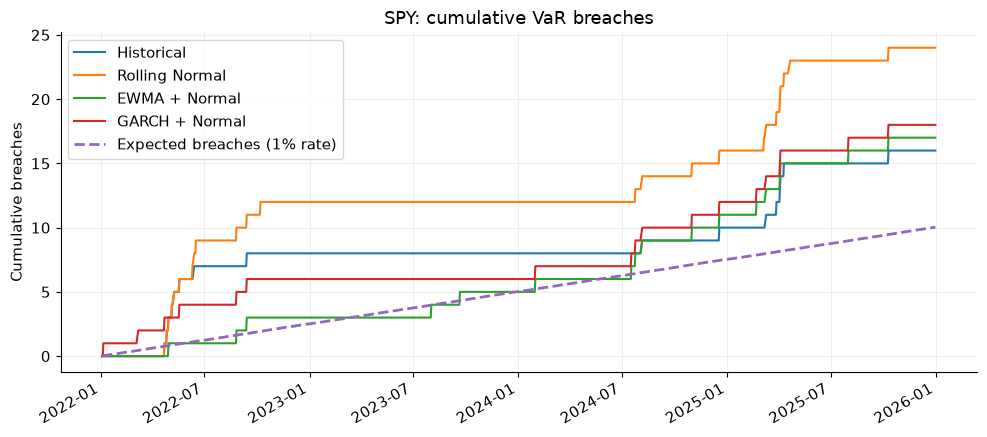

In [7]:
expected = np.arange(1, len(test_loss)+1) * (1-CONFIDENCE)
fig, ax = plt.subplots(figsize=(10, 4.5))

for model in forecasts.columns:
    hits = (test_loss > forecasts[model]).astype(int)
    ax.plot(hits.index, hits.cumsum(), label=model)

ax.plot(test_loss.index, expected, linestyle="--", linewidth=2, label=f"Expected breaches ({1-CONFIDENCE:.0%} rate)")
ax.set(title=f"{CASE}: cumulative VaR breaches",
       ylabel="Cumulative breaches", xlabel="")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Kupiec's unconditional-coverage test

Counting breaches is informative, but the realised count will not normally equal the expected count exactly. Kupiec's test asks whether the difference is large enough to reject the target breach probability.

Define the hit indicator

$$I_t=\begin{cases}
1,&\text{if Loss}_t>\text{VaR}_t,\\
0,&\text{otherwise.}
\end{cases}$$

If there are $x=\sum_t I_t$ breaches in $n$ forecast days, the observed breach probability is

$$\widehat p=\frac{x}{n}.$$

For 99% VaR, the hypotheses are

$$H_0:p=p_0=0.01,$$

$$H_1:p\neq0.01.$$

Under the Bernoulli/binomial coverage model, the log-likelihood is

$$\ell(p)=x\ln(p)+(n-x)\ln(1-p).$$

Kupiec's likelihood-ratio statistic compares the likelihood under the required probability $p_0$ with the likelihood maximised at the observed probability $\widehat p$:

$$LR_{uc}=2\left[\ell(\widehat p)-\ell(p_0)\right]
\overset{a}{\sim}\chi^2(1).$$

This corresponds directly to `null_loglik`, `fitted_loglik`, `lr_uc` and `p_value` in the code below.

- **p-value below 5%:** reject correct unconditional coverage;
- **p-value at least 5%:** do not reject coverage.

“Do not reject” does **not** prove that the model is correct. Kupiec uses the total breach count and ignores both the ordering of breaches and the severity of losses beyond VaR. The chi-squared reference distribution is asymptotic. Because only about 10 breaches are expected here, the exact-binomial companion in the next section is a useful robustness check; with the default course data, it gives the same 5% decisions.


In [8]:
target_probability = 1 - CONFIDENCE
kupiec_rows = []

for model in forecasts.columns:
    # Record 1 when realised loss exceeds VaR; otherwise record 0.
    hits = (test_loss > forecasts[model]).astype(int)
    n = len(hits)
    breaches = int(hits.sum())
    observed_probability = breaches / n

    # Likelihood when the breach probability equals the target rate.
    null_loglik = (
        xlogy(breaches, target_probability)
        + xlogy(n - breaches, 1 - target_probability)
    )

    # Likelihood when the probability equals the observed breach rate.
    fitted_loglik = (
        xlogy(breaches, observed_probability)
        + xlogy(n - breaches, 1 - observed_probability)
    )

    # Kupiec likelihood-ratio unconditional-coverage statistic.
    lr_uc = max(0.0, 2 * (fitted_loglik - null_loglik))
    p_value = chi2.sf(lr_uc, df=1)

    kupiec_rows.append({
        "Model": model,
        "Forecast days": n,
        "Breaches": breaches,
        "Expected breaches": n * target_probability,
        "Observed breach rate": observed_probability,
        "Kupiec LRuc": lr_uc,
        "Kupiec p-value": p_value,
        "Decision at 5%": (
            "Reject coverage" if p_value < 0.05 else "Do not reject coverage"
        ),
    })

kupiec_results = pd.DataFrame(kupiec_rows).set_index("Model")
display(kupiec_results.round(4))


,Forecast days,Breaches,Expected breaches,Observed breach rate,Kupiec LRuc,Kupiec p-value,Decision at 5%
Model,,,,,,,
Historical,1003,16,10.03,0.0160,3.0402,0.0812,Do not reject coverage
Rolling Normal,1003,24,10.03,0.0239,14.1362,0.0002,Reject coverage
EWMA + Normal,1003,17,10.03,0.0169,4.0486,0.0442,Reject coverage
GARCH + Normal,1003,18,10.03,0.0179,5.1766,0.0229,Reject coverage


### Why can Historical avoid rejection while GARCH + Normal is rejected?

With the default settings and frozen course data, Historical VaR has 16 breaches and a Kupiec p-value of 0.0812, while GARCH + Normal has 18 breaches and a p-value of 0.0229. Historical VaR also has a higher mean threshold—approximately USD 30,173 compared with USD 23,835 for GARCH + Normal—so it is more conservative and consequently harder to breach.

This does **not** prove that Historical VaR is the superior model. Historical narrowly avoids rejection, while the upper 5% rejection boundary in this sample falls between 16 and 17 breaches. Kupiec evaluates breach frequency, not forecast sharpness, economic usefulness or required capital. The rejected specification is the complete **zero-mean Normal GARCH(1,1) VaR model**. GARCH volatility may respond sensibly through time while the Normal tail assumption still understates extreme returns, particularly after calm periods when conditional volatility has declined.

The appropriate conclusions are therefore:

- Historical coverage is **not rejected**, rather than “proved correct”;
- GARCH + Normal is rejected on unconditional coverage for this evaluation period; and
- model sophistication alone does not guarantee well-calibrated tail-risk forecasts.


### Exact coverage and breach independence

Kupiec and the exact-binomial test examine the **same null hypothesis**:

$$H_0:\Pr(\text{breach})=0.01.$$

Kupiec uses an asymptotic chi-squared reference distribution. The exact test instead evaluates the breach count directly under

$$X\sim\operatorname{Binomial}(n,0.01).$$

They are two ways to assess the same coverage claim, not two independent votes. The exact test is especially useful when the expected tail count is small.

Coverage does not reveal whether breaches cluster. Christoffersen's independence test uses transitions between consecutive hit indicators:

- $n_{00}$: no breach followed by no breach;
- $n_{01}$: no breach followed by a breach;
- $n_{10}$: breach followed by no breach; and
- $n_{11}$: breach followed by another breach.

It compares

$$p_{01}=\Pr(I_t=1\mid I_{t-1}=0)$$

with

$$p_{11}=\Pr(I_t=1\mid I_{t-1}=1).$$

Under independence, these probabilities should be equal. A p-value below 5% rejects first-order independence. A larger p-value means **independence is not rejected**, not proved. Because there are relatively few breaches, this test can have limited power.


In [9]:
validation_test_rows = []

for model in forecasts.columns:
    hits = (test_loss > forecasts[model]).astype(int).to_numpy()
    n = len(hits)
    breaches = int(hits.sum())
    target_probability = 1 - CONFIDENCE

    # Exact two-sided binomial companion to the asymptotic Kupiec test.
    exact_p = binomtest(breaches, n, target_probability).pvalue

    # Count transitions between successive breach indicators.
    previous = hits[:-1]
    current = hits[1:]
    n00 = int(((previous == 0) & (current == 0)).sum())
    n01 = int(((previous == 0) & (current == 1)).sum())
    n10 = int(((previous == 1) & (current == 0)).sum())
    n11 = int(((previous == 1) & (current == 1)).sum())

    independence_lr = np.nan
    independence_p = np.nan

    # Estimate the breach probability after a non-breach and after a breach.
    if n00 + n01 > 0 and n10 + n11 > 0:
        p01 = n01 / (n00 + n01)
        p11 = n11 / (n10 + n11)
        shared_p = (n01 + n11) / (n - 1)

        # Null likelihood: one common transition probability.
        independent_loglik = (
            xlogy(n00 + n10, 1 - shared_p)
            + xlogy(n01 + n11, shared_p)
        )

        # Alternative likelihood: transition probability depends on the previous hit.
        dependent_loglik = (
            xlogy(n00, 1 - p01) + xlogy(n01, p01)
            + xlogy(n10, 1 - p11) + xlogy(n11, p11)
        )

        independence_lr = max(0.0, 2 * (dependent_loglik - independent_loglik))
        independence_p = chi2.sf(independence_lr, df=1)

    # A missing test statistic must not be reported as a successful non-rejection.
    if np.isnan(independence_p):
        independence_decision = "Not available"
    elif independence_p < 0.05:
        independence_decision = "Reject independence"
    else:
        independence_decision = "Do not reject independence"

    validation_test_rows.append({
        "Model": model,
        "Kupiec p-value": kupiec_results.loc[model, "Kupiec p-value"],
        "Exact binomial p-value": exact_p,
        "Exact coverage decision": (
            "Reject coverage" if exact_p < 0.05 else "Do not reject coverage"
        ),
        "Independence LR": independence_lr,
        "Independence p-value": independence_p,
        "Independence decision": independence_decision,
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11,
    })

validation_test_results = pd.DataFrame(validation_test_rows).set_index("Model")

# Display the statistical conclusions first.
display(validation_test_results[[
    "Kupiec p-value",
    "Exact binomial p-value",
    "Exact coverage decision",
    "Independence p-value",
    "Independence decision",
]].round(4))

# Display the transition evidence separately so the main table stays readable.
display(validation_test_results[["n00", "n01", "n10", "n11"]])


,Kupiec p-value,Exact binomial p-value,Exact coverage decision,Independence p-value,Independence decision
Model,,,,,
Historical,0.0812,0.0770,Do not reject coverage,0.2520,Do not reject independence
Rolling Normal,0.0002,0.0002,Reject coverage,0.1280,Do not reject independence
EWMA + Normal,0.0442,0.0369,Reject coverage,0.2887,Do not reject independence
GARCH + Normal,0.0229,0.0168,Reject coverage,0.3278,Do not reject independence


,n00,n01,n10,n11
Model,,,,
Historical,971,15,15,1
Rolling Normal,956,22,22,2
EWMA + Normal,969,16,16,1
GARCH + Normal,967,17,17,1


### Reading the coverage and independence results

With the default course data, Kupiec and the exact-binomial test give the same 5% coverage decisions. Historical coverage is not rejected, while Rolling Normal, EWMA + Normal and GARCH + Normal are rejected.

First-order independence is not rejected for any procedure. This means the test does not find sufficiently strong evidence that a breach changes the probability of a breach on the next day. It does **not** establish that breaches are truly independent. The transition table shows why caution is necessary: breach-followed-by-breach observations, $n_{11}$, are very sparse.


### Quantile scoring: coverage is not the whole story

Coverage tests count breaches but ignore the size and direction of forecast errors. For realised loss $L_t$, VaR forecast $q_t$ and quantile level $\tau=0.99$, the pinball or quantile score is

$$S_{\tau}(L_t,q_t)=
\begin{cases}
\tau(L_t-q_t),&L_t\ge q_t,\\
(1-\tau)(q_t-L_t),&L_t<q_t.
\end{cases}$$

At 99%, each dollar of underprediction receives weight 0.99, while each dollar of overprediction receives weight 0.01. This asymmetry is appropriate for estimating a high loss quantile. **Lower average score is better.**

The score complements rather than replaces coverage and independence tests. A low score does not prove correct coverage. Dollar scores should be compared only across forecasts for the same position, exposure, horizon and confidence level.


In [10]:
score_rows = []

for model in forecasts.columns:
    q = forecasts[model]
    error = test_loss - q

    # Pinball loss for the 99% loss quantile.
    score = np.where(
        error >= 0,
        CONFIDENCE * error,
        (CONFIDENCE - 1) * error,
    )

    score_rows.append({
        "Model": model,
        "Mean VaR (USD)": q.mean(),
        "Mean excess loss on breaches (USD)": error[error > 0].mean(),
        "Mean quantile score (USD)": score.mean(),
    })

score_results = pd.DataFrame(score_rows).set_index("Model")
display(score_results.round(2))


,Mean VaR (USD),Mean excess loss on breaches (USD),Mean quantile score (USD)
Model,,,
Historical,30173.43,9990.43,465.91
Rolling Normal,25371.36,9961.36,496.87
EWMA + Normal,24325.97,7559.36,376.19
GARCH + Normal,23834.65,7614.33,379.80


### Reading the quantile scores

Historical VaR is not rejected by the coverage tests, but it has a higher mean VaR and a higher quantile score than the conditional EWMA + Normal and GARCH + Normal procedures. It achieves fewer breaches partly by being more conservative.

EWMA + Normal and GARCH + Normal have lower quantile scores, meaning that their complete sequences of 99% quantile forecasts are more accurate under this scoring rule. However, both still fail the 1% coverage requirement. No procedure should be declared “best” from one diagnostic alone.


### Inspect one model in detail

The next chart shows realised daily losses, the VaR threshold and breach dates for one selected model. Change `MODEL_TO_INSPECT` to `"Rolling Normal"`, `"EWMA + Normal"` or `"GARCH + Normal"` if you want to inspect another model without producing four large charts at once.


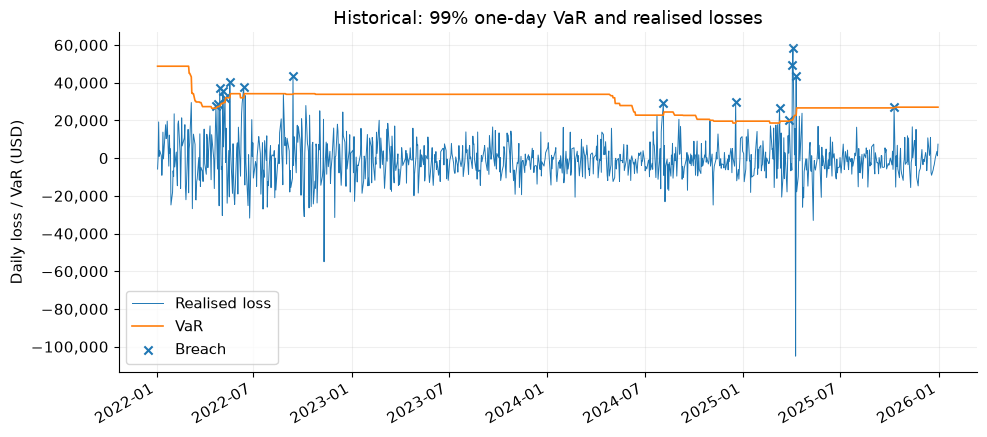

In [11]:
MODEL_TO_INSPECT = "Historical"
hits = test_loss > forecasts[MODEL_TO_INSPECT]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(test_loss.index, test_loss, linewidth=.7, label="Realised loss")
ax.plot(forecasts.index, forecasts[MODEL_TO_INSPECT], linewidth=1.2, label="VaR")
ax.scatter(test_loss.index[hits], test_loss[hits], marker="x", s=35, label="Breach")
ax.set(title=f"{MODEL_TO_INSPECT}: {CONFIDENCE:.0%} one-day VaR and realised losses",
       ylabel="Daily loss / VaR (USD)", xlabel="")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Checkpoint 1.** In 5–7 sentences:

1. identify which procedures have more breaches than expected;
2. state whether Kupiec and exact-binomial coverage conclusions agree;
3. state what the independence tests do—and do not—show;
4. compare Historical and GARCH + Normal using mean VaR and quantile score; and
5. explain why no procedure can be declared correct from one diagnostic alone.

In [12]:
answer_1 = ""


## 4 · Core conclusion: what has the backtest taught us?

The purpose of the backtest is **not** to find the model with the smallest VaR or to force the breach count to equal the expected number exactly.

A defensible conclusion combines several pieces of evidence:

- **Kupiec coverage:** is the overall breach rate consistent with 1%?
- **Exact coverage:** is that conclusion robust without relying on the chi-squared approximation?
- **Independence:** is there evidence that breaches depend on the preceding day's breach state?
- **Quantile score:** how accurate is the complete sequence of VaR forecasts under a proper scoring rule?
- **Mean VaR and excess loss:** how conservative are the forecasts, and how serious are their failures?

A key lesson is that a VaR model must be judged by **out-of-sample performance**, not by sophistication alone. A model that is not rejected by one test has not been proved correct, while a model with a low quantile score may still have incorrect coverage.


### Core capstone · Write 150–200 words to the risk manager

Using the **SPY backtest only**, write a short note that:

- states the one-day horizon, 99% confidence level and evaluation period;
- compares **two** VaR forecasting procedures using breach counts and mean VaR;
- reports and interprets their Kupiec results and states whether the exact-binomial conclusions agree;
- interprets the independence-test evidence cautiously;
- compares their quantile scores;
- explains whether either procedure appears to underestimate risk or to be especially conservative; and
- gives **one** practical recommendation plus **one** limitation of the backtest.

Do not write that a model is “safe”, “correct” or “independent” simply because a p-value exceeds 5%. Integrate the evidence into a defensible risk-management judgement.


In [13]:
memo = """Write your SPY backtest memo here."""


> **Core notebook complete.** Everything below this point is optional extension material.


# Optional extension 1 · Model sensitivity

These exercises explore how implementation choices affect a backtest. They are **not** part of the core route, and the aim is not to tune a model until it produces exactly the expected number of breaches.

1. **Window choice:** compare `WINDOW = 250`, `500`, `750` or `1000` while keeping the test dates fixed. Record breach counts and mean VaR. Which forecasting procedures are most sensitive to the amount of history used?
2. **Confidence sensitivity:** change `CONFIDENCE` from 99% to 95%. How do VaR and the expected number of breaches change?
3. **GARCH refit frequency:** compare `REFIT_EVERY = 1`, `21` and `63`. Does the breach count change materially? Remember that conditional variance is still updated every day.
4. **Advanced — Student-t GARCH:** replace Normal GARCH shocks with Student-t shocks and use the corresponding **unit-variance-standardised Student-t quantile** when calculating VaR. Does allowing fatter tails change the breach result?
5. **Fixed-parameter holdout:** estimate GARCH once using observations before `TEST_START`, freeze $\omega$, $\alpha$ and $\beta$ during the evaluation period, but continue updating conditional variance after each observed return. Compare this parameter-stability test with the periodically refitted procedure.

**Interpretation rule:** a setting that happens to give a breach count close to the target in this test sample is not automatically the universally “best” setting.

# Optional extension 2 · From a single position to a simplified bank trading book

This extension introduces **multiple market-risk exposures**. It is not required for the core SPY backtest.

A bank trading book is not a portfolio of bank shares. We map four simplified market-risk exposures into dollar P&L.

| Position | If the risk factor rises | If the risk factor falls |
|---|---|---|
| Long US equity | gain | loss |
| Long NZD vs USD | gain if NZD appreciates | loss if NZD depreciates |
| Rate exposure with DV01 = USD 6,500/bp | loss when yield rises | gain when yield falls |
| Long gold | gain | loss |

Read the **sign and unit** of every exposure before calculating total P&L.


In [14]:
EQUITY_USD = 4_000_000  # Fixed equity exposure in USD.
FX_USD = 3_000_000  # USD value of a long NZD exposure before each scenario.
DV01 = 6_500  # USD loss per basis-point rise for the rate exposure.
GOLD_USD = 1_500_000  # Fixed gold exposure in USD.
position_table = pd.DataFrame({"Exposure": [EQUITY_USD, FX_USD, DV01, GOLD_USD],
    "Unit": ["USD", "USD value of NZD", "USD per basis point", "USD"],
    "Risk factor": ["SPY return", "NZD/USD return", "10-year yield change", "GLD return"]},
    index=["Equity", "FX", "Rates", "Gold"])  # Make positions and units explicit.
display(position_table)  # Read the units before calculating P&L.


,Exposure,Unit,Risk factor
Equity,4000000,USD,SPY return
FX,3000000,USD value of NZD,NZD/USD return
Rates,6500,USD per basis point,10-year yield change
Gold,1500000,USD,GLD return


## E2.1 · Map risk factors into dollars

$$P\&L_t=N_Er_{SPY,t}+N_{FX}r_{NZDUSD,t}-DV01\,\Delta y_t^{bp}+N_Gr_{GLD,t}.$$

Price and FX changes are decimal returns. Yield changes are measured in **basis points**, not percentage returns.

For example, a yield move from 4.20% to 4.70% is 50 bp. With a DV01 of USD 6,500 per bp, the rate position loses USD 325,000.

A +1% move in NZD/USD benefits the long-NZD position by approximately USD 30,000 when `FX_USD = 3,000,000`.

This is intentionally simplified: DV01 is a first-order sensitivity and the ETF/FX/yield series are classroom risk-factor proxies, not a complete bank market-risk system.


In [15]:
yield_change_bp = (4.70-4.20)*100
print(f"Yield change: {yield_change_bp:.0f} bp; rate P&L: ${-DV01*yield_change_bp:,.0f}")
factors = pd.DataFrame({"SPY": data.SPY.pct_change(fill_method=None),
                        "NZDUSD": data.NZDUSD.pct_change(fill_method=None),
                        "Yield bp": data.US10Y_YIELD_PCT.diff()*100,
                        "GLD": data.GLD.pct_change(fill_method=None)}).iloc[1:]
components = pd.DataFrame({"Equity": EQUITY_USD*factors.SPY,
                           "FX": FX_USD*factors.NZDUSD,
                           "Rates": -DV01*factors["Yield bp"],
                           "Gold": GOLD_USD*factors.GLD})
# Add the four position P&Ls to obtain the bank total.
bank_pnl = components.sum(axis=1)
# Select a day to trace each position contribution.
day = factors.index[100]
display(factors.loc[day].to_frame("Factor change: returns decimal; yield bp"))
display(components.loc[day].to_frame("Component P&L (USD)"))
print(f"Bank total P&L on {day.date()}: ${bank_pnl.loc[day]:,.2f}")
assert np.isclose(components.loc[day].sum(), bank_pnl.loc[day])


Yield change: 50 bp; rate P&L: $-325,000


,Factor change: returns decimal; yield bp
SPY,-0.006213
NZDUSD,-0.008117
Yield bp,-3.500008
GLD,0.000702


,Component P&L (USD)
Equity,-24852.669014
FX,-24351.637407
Rates,22750.052000
Gold,1052.471045


Bank total P&L on 2015-05-29: $-25,401.78


**Checkpoint 2.** If the bank becomes **short NZD** instead of long NZD, what happens to the FX P&L when NZD depreciates? Why would `pct_change()` on the yield be the wrong measure for a DV01 position?


In [16]:
answer_2 = ""


### Investigate one large observed bank loss

Use the worst bank loss within the evaluation period to trace the loss back to its positions. This is an **ex-post explanation**, not a forecast.

The market series share date labels, but their exact market-close times may differ. Treat the result as a classroom approximation rather than a production trading-book reconstruction.


In [17]:
# Identify bank losses during the evaluation period.
bank_test_loss = -bank_pnl.loc[test_index]
# Locate the date of the largest bank loss.
worst_day = bank_test_loss.idxmax()
display(pd.DataFrame({"P&L (USD)": components.loc[worst_day],
                      "Loss contribution (USD)": -components.loc[worst_day]}).round(2))
print(f"Bank worst test-day loss: {worst_day.date()}, ${bank_test_loss.loc[worst_day]:,.0f}")


,P&L (USD),Loss contribution (USD)
Equity,-151872.51,151872.51
FX,-22738.09,22738.09
Rates,-136500.03,136500.03
Gold,-39618.43,39618.43


Bank worst test-day loss: 2022-06-13, $350,729


## E2.2 · Stress testing asks a different question from VaR

VaR asks for a loss quantile under a model or historical distribution. A stress test instead asks:

> **What would happen to this portfolio if a specified joint shock occurred?**

The scenarios below are hypothetical and are **not assigned a 99% probability**. Their purpose is to reveal which positions drive losses under particular market stories.


,Bank stress loss (USD),Largest loss driver
Equity crash,702500.0,Equity
Inflation / rate shock,850000.0,Rates
Liquidity sell-off,950000.0,Rates


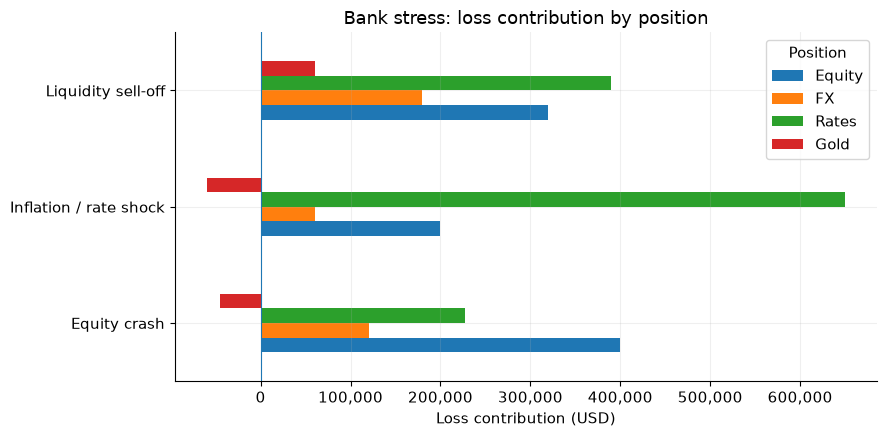

In [18]:
scenarios = pd.DataFrame({
    "Equity crash": {"SPY": -.10, "NZDUSD": -.04, "Yield bp": 35, "GLD": .03},
    "Inflation / rate shock": {"SPY": -.05, "NZDUSD": -.02, "Yield bp": 100, "GLD": .04},
    "Liquidity sell-off": {"SPY": -.08, "NZDUSD": -.06, "Yield bp": 60, "GLD": -.04},
}).T

stress_components = pd.DataFrame({
    "Equity": EQUITY_USD*scenarios.SPY,
    "FX": FX_USD*scenarios.NZDUSD,
    "Rates": -DV01*scenarios["Yield bp"],
    "Gold": GOLD_USD*scenarios.GLD,
})
stress_losses = -stress_components.sum(axis=1)

stress_summary = pd.DataFrame({
    "Bank stress loss (USD)": stress_losses,
    "Largest loss driver": stress_components.idxmin(axis=1),
})
display(stress_summary.round(0))

fig, ax = plt.subplots(figsize=(9, 4.5))
(-stress_components).plot.barh(ax=ax)
ax.axvline(0, linewidth=.8)
ax.set(title="Bank stress: loss contribution by position",
       xlabel="Loss contribution (USD)", ylabel="")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(title="Position")
plt.tight_layout()
plt.show()


## E2.3 · Report investment risk and bank risk separately

The table below calculates historical VaR and ES using the latest `WINDOW` losses for the SPY investment and the simplified bank book.

Two cautions matter:

1. only the SPY forecasting procedures were backtested above; the bank VaR has **not** been validated here; and
2. stress losses are hypothetical scenario losses, not VaR estimates with the same probability interpretation.

The numbers are teaching estimates, not regulatory capital calculations.


In [19]:
report_rows = []  # Collect the two distinct exposure reports.
for label, losses, stress in [("SPY investment", loss, -SPY_VALUE*scenarios.SPY), ("Bank book", -bank_pnl, stress_losses)]:
    var, es = empirical_tail(losses.iloc[-WINDOW:], CONFIDENCE)  # Use the same window length and confidence.
    report_rows.append({"Case": label, "Information through": data.index[-1].date(),
        "Horizon": "One trading day", "Confidence": CONFIDENCE, "Observations": WINDOW,
        "Historical VaR (USD)": var, "Historical ES (USD)": es,
        "Largest hypothetical stress (USD)": stress.max(), "Worst scenario": stress.idxmax()})  # Keep scenario losses separate.
display(pd.DataFrame(report_rows).set_index("Case"))  # Compare interpretation, not just dollar size.


,Information through,Horizon,Confidence,Observations,Historical VaR (USD),Historical ES (USD),Largest hypothetical stress (USD),Worst scenario
Case,,,,,,,,
SPY investment,2025-12-31,One trading day,0.99,500,27027.862183,42114.054194,100000.0,Equity crash
Bank book,2025-12-31,One trading day,0.99,500,154884.054522,209789.884427,950000.0,Liquidity sell-off


### Optional bank extension reflection

In 100–150 words:

- identify the bank's largest observed loss and largest hypothetical stress loss;
- explain which position is the main loss driver in the worst stress scenario;
- distinguish the historical VaR/ES numbers from the stress-scenario loss; and
- state one limitation of this simplified bank-book exercise.


In [20]:
bank_reflection = """Write your optional bank-book reflection here."""


### Optional bank-extension practice

1. Change `FX_USD` from +3m to −3m. Predict the effect before rerunning, then check the bank P&L and stress losses.
2. Add one coherent stress scenario involving NZD depreciation and a rate rise.
3. Explain why `pct_change()` on the yield would be the wrong input for a DV01 position.
